In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')

In [3]:
# 设置标的和日期
instrument_id = '518880'
trade_ymd = '20251219'

# 策略参数配置
param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_demo',
    'stride': 1,

    'short_window': 60,      # 短期窗口
    'long_window': 300,      # 长期窗口
    'y_window': 300,         # 标签窗口

    'open_threshold': 2,     # 开仓阈值
    'open_confidence': 0,    # 开仓置信度
    'close_confidence': 0.2, # 平仓置信度
    'standard_num': 1000,    # 标准数量

    'atr_multiplier': 4,     # 回撤比例
    'vol_window': 900,       # 价格波动窗口

    'k_up': 3,
    'k_down': 3,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

In [4]:
model_path = f"/home/jovyan/work/model/delta_v3.pkl"
import joblib
model = joblib.load(model_path)
print(f"模型已加载: {model_path}")

模型已加载: /home/jovyan/work/model/delta_v3.pkl


In [5]:
from delta import strategy 
tactic = strategy.StrategyDemo(model_path, param_dict)

In [6]:
# 单日回测测试
sys.path.append('/home/jovyan/base_demo')
import base_tool
snap_list = base_tool.snap_list_load(instrument_id, trade_ymd)

position_dict = {}
for snap in snap_list:
    tactic.on_snap(snap)
    position_dict[snap['time_mark']] = tactic.position_last

print(f"生成 {len(position_dict)} 个仓位信号")

生成 14402 个仓位信号


## 并行回测（修复版）

使用修复的并行回测函数：

In [10]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest

# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id="518880",
    start_ymd="20251201",
    end_ymd="20251231",
    StrategyClass=strategy.StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4
)

if result_df is not None:
    print("\n并行回测结果汇总:")
    print(result_df)
    print(f"\n累计盈亏: {result_df['profits'].sum():.2f}")
else:
    print("并行回测失败")

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 回测标的: 518880 (20251201 - 20251231)
-> 任务分配: 共 31 天，使用 4 个核心并行计算...


[SpawnPoolWorker-23] 日期 20251217 完成 | 盈亏: -1.80
[SpawnPoolWorker-25] 日期 20251225 完成 | 盈亏: 2.60
[SpawnPoolWorker-22] 日期 20251201 完成 | 盈亏: 1.40
[SpawnPoolWorker-24] 日期 20251209 完成 | 盈亏: 3.80
[SpawnPoolWorker-22] 日期 20251202 完成 | 盈亏: 0.80
[SpawnPoolWorker-23] 日期 20251218 完成 | 盈亏: -2.80
[SpawnPoolWorker-25] 日期 20251226 完成 | 盈亏: -1.10

instrument_id 511090
20251201
20251202
20251203
20251204
20251205
20251208
20251209
20251210
20251211
20251212
20251215
20251216
20251217
20251218
20251219
20251222
20251223
20251224
20251225
20251226
20251229
20251230
20251231
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227

instrument_id 511100
20251201
20251202
20251203
20251204
20251205
20251208
20251209
20251210
20251211
20251212
20251215
20251216
202

TimeoutError: 

/home/jovyan/work/backtest_result/518880_20251219_delta_v1_demo.pkl 已请求


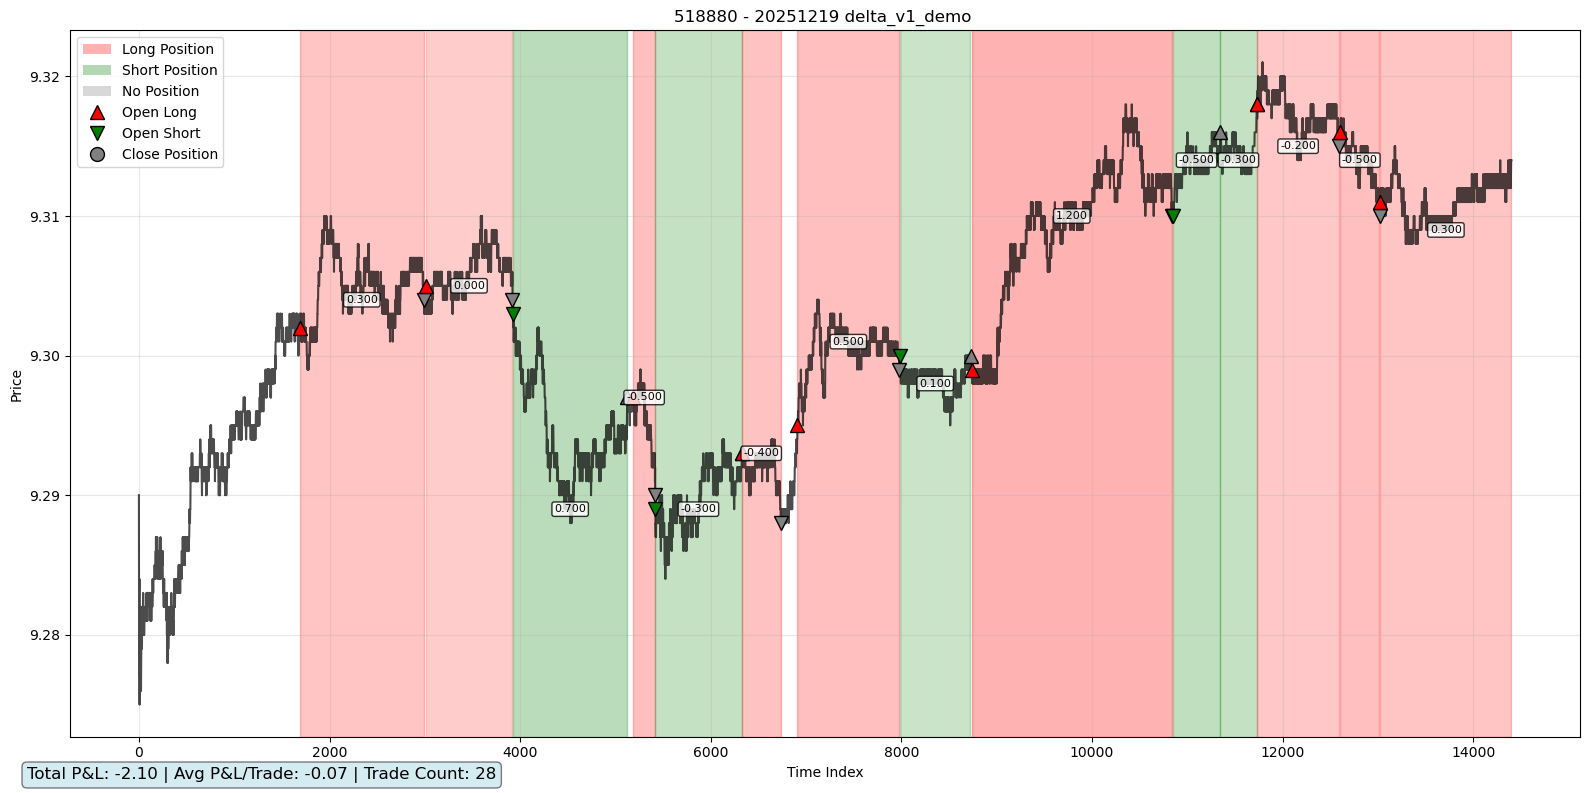

In [ ]:
# 执行单日回测
import sys
sys.path.append('/home/jovyan/work/tactics_demo/tools')

from single_day_backtest import single_day_backtest

profit_df = single_day_backtest(
    instrument_id=instrument_id,
    trade_ymd=trade_ymd,
    StrategyClass=strategy.StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    official= True, 
)